In [34]:
import sys

In [35]:
!{sys.executable} -m pip uninstall -y numpy pandas pandas-datareader
!{sys.executable} -m pip install numpy==1.23.5 pandas==1.5.3 pandas-datareader==0.10.0


Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
Found existing installation: pandas 1.5.3
Uninstalling pandas-1.5.3:
  Successfully uninstalled pandas-1.5.3
Found existing installation: pandas-datareader 0.10.0
Uninstalling pandas-datareader-0.10.0:
  Successfully uninstalled pandas-datareader-0.10.0
  Using cached numpy-1.23.5-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
  Using cached pandas-1.5.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.1 MB)
  Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [36]:
import numpy as np
import pandas as pd

print(np.__version__)
print(pd.__version__)


1.23.5
1.5.3


In [37]:
import pandas_datareader as pdr
key="1877dbb9a56522ba7345ad7a1a9c26e2118f6894"

In [38]:
df = pdr.get_data_tiingo("GOOG", api_key=key)


/tmp/ipykernel_10708/2103459282.py:1: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  df = pdr.get_data_tiingo("GOOG", api_key=key)


In [39]:

df.head()


close     high       low     open  \
symbol date                                                             
GOOG   2021-03-04 00:00:00+00:00  2049.09  2089.24  2020.270  2023.37   
       2021-03-05 00:00:00+00:00  2108.54  2118.11  2046.415  2073.12   
       2021-03-08 00:00:00+00:00  2024.17  2128.81  2021.610  2101.13   
       2021-03-09 00:00:00+00:00  2052.70  2078.04  2047.830  2070.00   
       2021-03-10 00:00:00+00:00  2055.03  2075.00  2033.370  2071.76   

                                   volume    adjClose     adjHigh      adjLow  \
symbol date                                                                     
GOOG   2021-03-04 00:00:00+00:00  2118006  101.685553  103.677986  100.255368   
       2021-03-05 00:00:00+00:00  2195218  104.635744  105.110652  101.552807   
       2021-03-08 00:00:00+00:00  1647429  100.448905  105.641637  100.321865   
       2021-03-09 00:00:00+00:00  1697306  101.864698  103.122189  101.623026   
       2021-03-10 00:00:00+00:00  1268592  101.980324  102.971330  100.905452   

                                     adjOpen  adjVolume  divCash  splitFactor  
symbol date                                                                    
GOOG   2021-03-04 00:00:00+00:00  100.409205   42360120      0.0          1.0  
       2021-03-05 00:00:00+00:00  102.878036   43904360      0.0          1.0  
       2021-03-08 00:00:00+00:00  104.268024   32948580      0.0          1.0  
       2021-03-09 00:00:00+00:00  102.723206   33946120      0.0          1.0  
       2021-03-10 00:00:00+00:00  102.810546   25371840      0.0          1.0

In [40]:
df.to_csv('GOOGLE.csv')

In [41]:
import pandas as pd
df=pd.read_csv('GOOGLE.csv')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2021-03-04 00:00:00+00:00,2049.09,2089.24,2020.270,2023.37,2118006,101.685553,103.677986,100.255368,100.409205,42360120,0.0,1.0
1,GOOG,2021-03-05 00:00:00+00:00,2108.54,2118.11,2046.415,2073.12,2195218,104.635744,105.110652,101.552807,102.878036,43904360,0.0,1.0
2,GOOG,2021-03-08 00:00:00+00:00,2024.17,2128.81,2021.610,2101.13,1647429,100.448905,105.641637,100.321865,104.268024,32948580,0.0,1.0
3,GOOG,2021-03-09 00:00:00+00:00,2052.70,2078.04,2047.830,2070.00,1697306,101.864698,103.122189,101.623026,102.723206,33946120,0.0,1.0
4,GOOG,2021-03-10 00:00:00+00:00,2055.03,2075.00,2033.370,2071.76,1268592,101.980324,102.971330,100.905452,102.810546,25371840,0.0,1.0


In [43]:
# Fix Google 20-for-1 stock split on July 18, 2022
df['date'] = pd.to_datetime(df['date'], utc=True)  # keep UTC timezone
split_date = pd.Timestamp('2022-07-18', tz='UTC')   # make split_date UTC-aware too

df.loc[df['date'] < split_date, 'close'] = df.loc[df['date'] < split_date, 'close'] / 20

df1 = df.reset_index()['close']
df1

0       102.4545
1       105.4270
2       101.2085
3       102.6350
4       102.7515
          ...   
1249    310.9200
1250    313.0300
1251    307.1500
1252    311.4300
1253    306.3600
Name: close, Length: 1254, dtype: float64

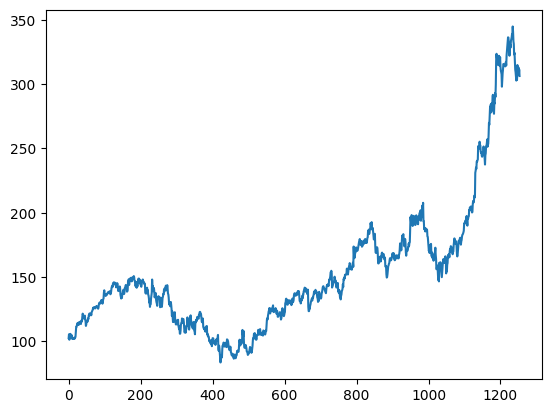

In [44]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [45]:
import numpy as np

In [46]:
df1

0       102.4545
1       105.4270
2       101.2085
3       102.6350
4       102.7515
          ...   
1249    310.9200
1250    313.0300
1251    307.1500
1252    311.4300
1253    306.3600
Name: close, Length: 1254, dtype: float64

In [47]:
from sklearn.preprocessing import MinMaxScaler

# Split RAW data first
training_size = int(len(df1)*0.65)
test_size = len(df1) - training_size
train_raw = np.array(df1[0:training_size]).reshape(-1,1)
test_raw = np.array(df1[training_size:]).reshape(-1,1)

# Then scale separately
scaler = MinMaxScaler(feature_range=(0,1))
train_data = scaler.fit_transform(train_raw)   # fit ONLY on train
test_data = scaler.transform(test_raw)          # only transform testfrom sklearn.preprocessing import MinMaxScaler

# Split RAW data first
training_size = int(len(df1)*0.65)
test_size = len(df1) - training_size
train_raw = np.array(df1[0:training_size]).reshape(-1,1)
test_raw = np.array(df1[training_size:]).reshape(-1,1)

# Then scale separately
scaler = MinMaxScaler(feature_range=(0,1))
train_data = scaler.fit_transform(train_raw)   # fit ONLY on train
test_data = scaler.transform(test_raw)          # only transform test

In [48]:
training_size,test_size

(815, 439)

In [49]:
train_data

array([[0.19744404],
       [0.22839146],
       [0.18447163],
       [0.19932327],
       [0.20053618],
       [0.23163457],
       [0.20412285],
       [0.20650182],
       [0.22005206],
       [0.21930245],
       [0.1907444 ],
       [0.19437793],
       [0.19197814],
       [0.19945862],
       [0.19534617],
       [0.19498178],
       [0.19039563],
       [0.2010151 ],
       [0.20080167],
       [0.20761583],
       [0.24359708],
       [0.28930245],
       [0.288886  ],
       [0.30186361],
       [0.31006767],
       [0.32070796],
       [0.30452369],
       [0.3110203 ],
       [0.30454971],
       [0.32631963],
       [0.32689224],
       [0.32930765],
       [0.32474232],
       [0.32456533],
       [0.31135867],
       [0.3360229 ],
       [0.34197814],
       [0.33176471],
       [0.36965643],
       [0.39567413],
       [0.38538261],
       [0.37760021],
       [0.3562988 ],
       [0.357595  ],
       [0.37040604],
       [0.37943259],
       [0.34974492],
       [0.332

In [50]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100 
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [51]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [52]:
print(X_train.shape), print(y_train.shape)

(714, 100)
(714,)


(None, None)

In [53]:
print(X_test.shape), print(ytest.shape)

(338, 100)
(338,)


(None, None)

In [54]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [55]:
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [56]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

In [57]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 100, 50)           10400     
                                                                 
 lstm_4 (LSTM)               (None, 100, 50)           20200     
                                                                 
 lstm_5 (LSTM)               (None, 50)                20200     
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 50851 (198.64 KB)
Trainable params: 50851 (198.64 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [58]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
12/12 [==============================] - 4s 125ms/step - loss: 0.0672 - val_loss: 0.6092
Epoch 2/100
12/12 [==============================] - 1s 74ms/step - loss: 0.0134 - val_loss: 0.2891
Epoch 3/100
12/12 [==============================] - 1s 69ms/step - loss: 0.0085 - val_loss: 0.3176
Epoch 4/100
12/12 [==============================] - 1s 73ms/step - loss: 0.0057 - val_loss: 0.2738
Epoch 5/100
12/12 [==============================] - 1s 73ms/step - loss: 0.0045 - val_loss: 0.1953
Epoch 6/100
12/12 [==============================] - 1s 71ms/step - loss: 0.0041 - val_loss: 0.1595
Epoch 7/100
12/12 [==============================] - 1s 72ms/step - loss: 0.0039 - val_loss: 0.1351
Epoch 8/100
12/12 [==============================] - 1s 69ms/step - loss: 0.0039 - val_loss: 0.1180
Epoch 9/100
12/12 [==============================] - 1s 67ms/step - loss: 0.0038 - val_loss: 0.1157
Epoch 10/100
12/12 [==============================] - 1s 66ms/step - loss: 0.0038 - val_loss: 0.111

In [59]:
import tensorflow as tf

In [60]:
tf.__version__

'2.15.0'

In [61]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

11/11 [==============================] - 0s 15ms/step


In [62]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [63]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

127.77750304568818

In [64]:
### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

222.45630401107775

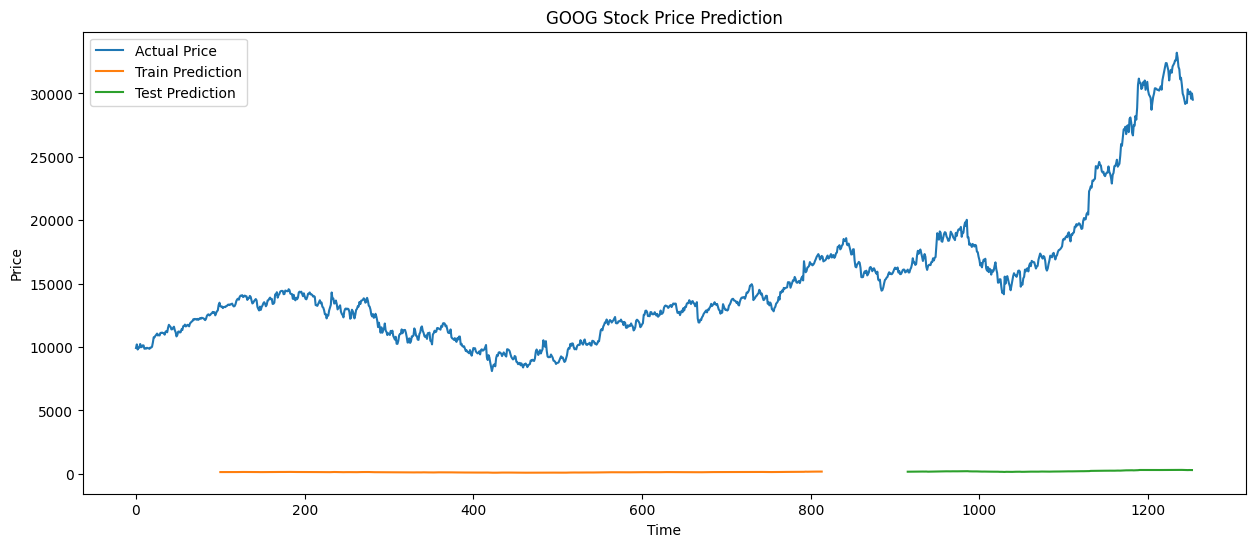

In [69]:
### Plotting
import numpy
import matplotlib.pyplot as plt

look_back = 100

# df1 needs to be 2D for inverse_transform
df1_2d = df1.values.reshape(-1, 1)

# shift train predictions for plotting
trainPredictPlot = numpy.empty_like(df1_2d)
trainPredictPlot[:, :] = numpy.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict

# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1_2d)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1_2d)-1, :] = test_predict

# plot baseline and predictions
plt.figure(figsize=(15, 6))
plt.plot(scaler.inverse_transform(df1_2d), label='Actual Price')
plt.plot(trainPredictPlot, label='Train Prediction')
plt.plot(testPredictPlot, label='Test Prediction')
plt.legend()
plt.title('GOOG Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()

                     Date  Predicted Close Price
2026-03-03 00:00:00+00:00             380.343292
2026-03-04 00:00:00+00:00             365.094055
2026-03-05 00:00:00+00:00             367.496002
2026-03-06 00:00:00+00:00             371.453125
2026-03-09 00:00:00+00:00             373.958160
2026-03-10 00:00:00+00:00             376.116089
2026-03-11 00:00:00+00:00             378.161255
2026-03-12 00:00:00+00:00             379.611145
2026-03-13 00:00:00+00:00             378.687103
2026-03-16 00:00:00+00:00             373.732605


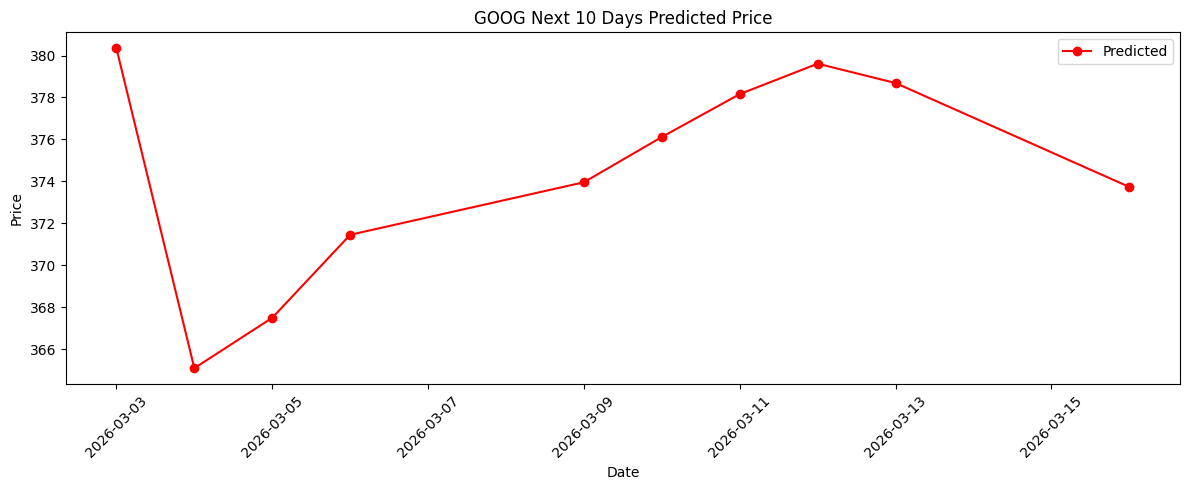

In [71]:
### Predict Next 10 Days
import numpy as np

# Take the last 100 days from the scaled data as input
last_100_days = df1_2d[len(df1_2d) - look_back:]  # shape (100, 1)

predictions = []
current_input = last_100_days.copy()

for i in range(10):
    # Reshape to (1, 100, 1) for LSTM input
    x_input = current_input.reshape(1, look_back, 1)
    
    # Predict next day
    next_pred = model.predict(x_input, verbose=0)
    
    # Store prediction
    predictions.append(next_pred[0][0])
    
    # Slide the window - remove first day, add predicted day
    current_input = numpy.append(current_input[1:], next_pred).reshape(-1, 1)

# Inverse transform to get actual prices
predictions = numpy.array(predictions).reshape(-1, 1)
predictions_actual = scaler.inverse_transform(predictions)

# Display results
import pandas as pd
last_date = pd.to_datetime(df['date'].iloc[-1], utc=True)
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=10)  # business days only

result_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Close Price': predictions_actual.flatten()
})

print(result_df.to_string(index=False))

# Plot
plt.figure(figsize=(12, 5))
plt.plot(future_dates, predictions_actual, marker='o', color='red', label='Predicted')
plt.title('GOOG Next 10 Days Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()